In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [29]:
X,y = make_blobs(n_samples=800, centers=4,  n_features=2)

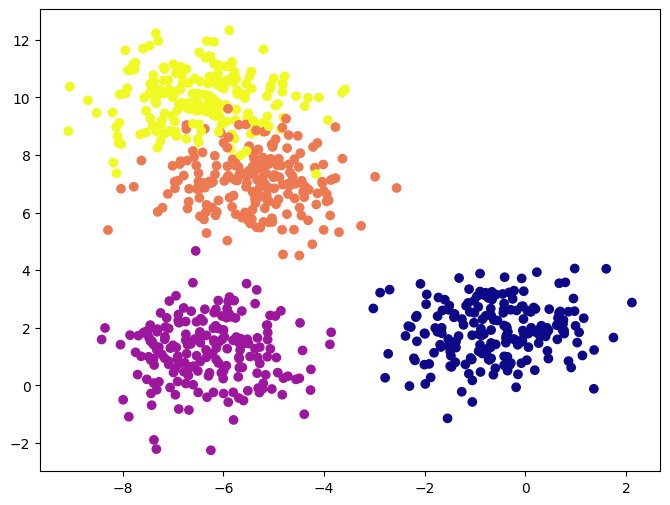

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X[: ,0],X[:,1], c=y, cmap='plasma')

#### Standardisation

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [38]:
wcss=[]

from sklearn.cluster import KMeans

for k in range(1,11):
    model = KMeans(n_clusters=k,init='k-means++')
    model.fit(scaled_X_train)
    wcss.append(model.inertia_)

In [39]:
print(wcss)

[1199.9999999999995, 557.393893706859, 187.8870093229748, 171.163997399036, 109.53999211309791, 99.52621608255791, 90.90274487841398, 82.38516939753748, 65.76238027545455, 59.961990449345464]


### Plot elbow Curve

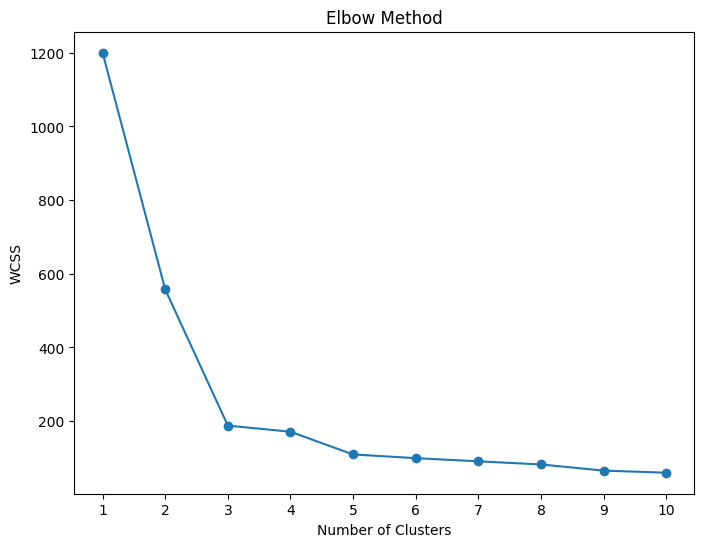

In [42]:

plt.figure(figsize=(8,6))
plt.plot(range(1,11),wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.xticks(range(1,11))
plt.ylabel('WCSS')
plt.show()

In [51]:
km=KMeans(n_clusters=3,init='k-means++')
km.fit_predict(scaled_X_train)

array([1, 1, 2, 0, 1, 1, 2, 1, 2, 2, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       2, 1, 0, 0, 1, 0, 1, 1, 1, 1, 2, 2, 1, 1, 1, 0, 1, 2, 0, 2, 0, 1,
       0, 1, 2, 1, 0, 1, 1, 1, 0, 1, 2, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 1, 2, 1, 1, 0, 0, 0, 0, 1, 0, 0, 2, 2, 2, 1, 1, 0, 0, 1,
       1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 2, 1, 2, 2,
       2, 2, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 2, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 2, 1, 1, 1, 1, 1, 2, 2, 1, 2, 0, 1, 0, 2, 0,
       1, 1, 2, 0, 1, 1, 2, 1, 1, 0, 0, 2, 2, 2, 1, 2, 1, 2, 1, 1, 1, 0,
       2, 2, 1, 2, 0, 1, 1, 2, 1, 1, 0, 1, 2, 1, 2, 2, 1, 1, 1, 1, 0, 1,
       0, 1, 2, 1, 2, 1, 1, 2, 1, 1, 1, 0, 1, 0, 2, 1, 1, 1, 0, 2, 0, 2,
       0, 2, 2, 1, 1, 0, 1, 2, 0, 1, 1, 1, 0, 2, 2, 1, 1, 0, 0, 1, 2, 1,
       1, 1, 0, 0, 2, 2, 2, 1, 0, 1, 2, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 2,
       0, 1, 1, 2, 0, 1, 2, 1, 2, 2, 1, 1, 0, 1, 0, 2, 0, 1, 1, 2, 1, 1,
       1, 1, 2, 2, 0, 2, 2, 1, 0, 1, 2, 1, 0, 2, 1,

In [52]:
y_pred=km.predict(scaled_X_test)

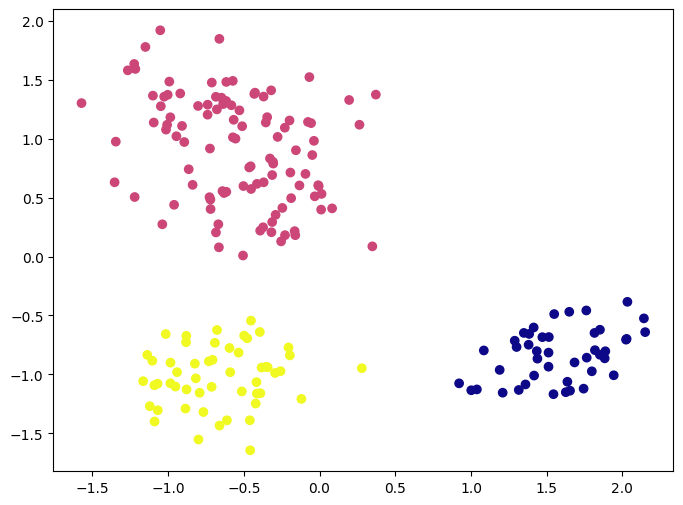

In [53]:
plt.figure(figsize=(8,6))
plt.scatter(scaled_X_test[:, 0], scaled_X_test[:, 1], c=y_pred, cmap='plasma')

### Validating the k value
##### kneeLocator
##### Silhoutee scoring

In [54]:
## kneeLocator
!pip install kneed

In [56]:
from kneed import KneeLocator
kl = KneeLocator(range(1,11), wcss, curve='convex', direction='decreasing')

In [57]:
kl.elbow

np.int64(3)

In [58]:
## silhouette scoring
from sklearn.metrics import silhouette_score
silhouette_coefficients=[]
for k in range(2,11):
    model = KMeans(n_clusters=k,init='k-means++')
    model.fit(scaled_X_train)
    score = silhouette_score(scaled_X_train, model.labels_)
    silhouette_coefficients.append(score)

In [ ]:
silhouette_coefficients

<class 'list'>


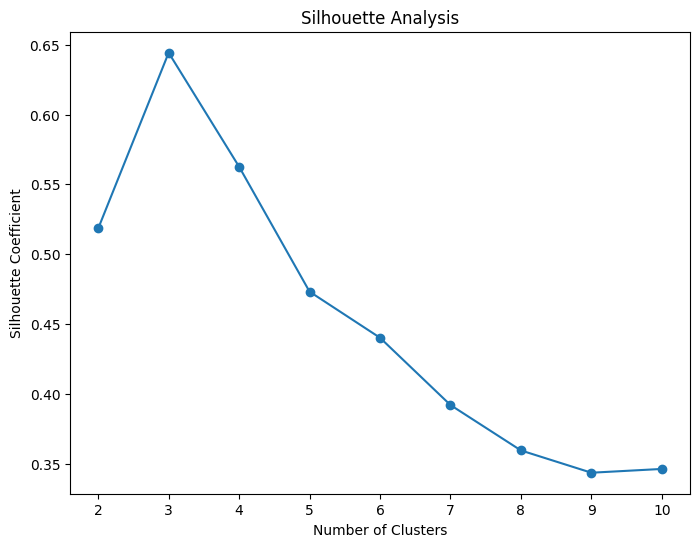

In [60]:

plt.figure(figsize=(8,6))
plt.plot(range(2,11),silhouette_coefficients, marker='o')
plt.title('Silhouette Analysis')
plt.xlabel('Number of Clusters')
plt.xticks(range(2,11))
plt.ylabel('Silhouette Coefficient')
plt.show()

In [67]:
max(silhouette_coefficients)
idx = silhouette_coefficients.index(max(silhouette_coefficients))
k=range(2,11)[idx]
print(f"Optimal number of clusters according to silhouette score: {k}")

Optimal number of clusters according to silhouette score: 3
